# 单 CV exact RTRL：三条 sensitivity、一条 learning signal

这个例子只使用一个 soma CV，并训练三个无量纲 conductance scale：`leak.scale`、`na.scale`、`k.scale`。因此在每个时间点：

```text
S_V(t,j) = partial V_t / partial theta_j       三个标量
L_V(t)   = partial loss_t / partial V_t        一个公共标量
g_t(j)   = S_V(t,j) * L_V(t)                   三个梯度贡献
```

如果参数 `theta_j` 改变一个小量 `delta`，则一阶近似为 `delta V_t = S_V(t,j) * delta`。本例 loss 不直接读取参数，所以 direct term `D_t=0`。

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")
root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "braincell").is_dir()
)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import braincell
import brainstate
import brainunit as u
import braintools
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

from braincell.filter import AllRegion, at
from validation.optim.gradient_correctness.multicv_hh import DT, simulate_voltage
from braincell.experimental.optim.gradients import build_rollout_value_and_grad

get_ipython().run_line_magic("matplotlib", "inline")
jax.config.update("jax_enable_x64", True)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## 1. 单 soma、单 CV、三个参数

Target 和 candidate 使用相同结构与刺激，但 target 的三个 conductance scale 不同。Candidate 从三个 scale 都等于 1 开始。

In [2]:
BASE_G_MAX = {
    "leak": 0.1 * u.mS / u.cm**2,
    "na": 120.0 * u.mS / u.cm**2,
    "k": 10.0 * u.mS / u.cm**2,
}
TARGET_SCALES = {"leak": 1.20, "na": 0.85, "k": 1.25}
NUM_STEPS = 400


def build_single_cv_cell(*, trainable, scales=None):
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um,
        radii=[10.0, 10.0] * u.um,
        type="soma",
    )
    morphology = braincell.Morphology.from_root(soma, name="soma")
    scale = {name: 1.0 for name in BASE_G_MAX} if scales is None else scales
    cell = braincell.Cell(
        morphology,
        cv_policy=braincell.CVPerBranch(),
        pop_size=(1,),
        V_init=-65.0 * u.mV,
        solver="staggered",
    )
    cell.paint(
        AllRegion(),
        braincell.mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        braincell.mech.Ion("SodiumFixed", E=50.0 * u.mV),
        braincell.mech.Ion("PotassiumFixed", E=-77.0 * u.mV),
        braincell.mech.Channel("IL", name="leak", g_max=scale["leak"] * BASE_G_MAX["leak"]),
        braincell.mech.Channel("Na_HH1952", name="na", g_max=scale["na"] * BASE_G_MAX["na"]),
        braincell.mech.Channel("K_HH1952", name="k", g_max=scale["k"] * BASE_G_MAX["k"]),
    )
    cell.place(
        at("soma", 0.5),
        braincell.mech.CurrentClamp(delay=0.0 * u.ms, durations=8.0 * u.ms, amplitudes=0.05 * u.nA),
    )
    if trainable:
        for name in ("leak", "na", "k"):
            cell.channels[name].trainable(g_max=braincell.trainable.scale(group_by="all", name=f"{name}.scale"))
    cell.init_state()
    return cell


times_ms = jnp.arange(NUM_STEPS, dtype=jnp.float64) * DT.to_decimal(u.ms)
with brainstate.environ.context(dt=DT, precision=64):
    target_cell = build_single_cv_cell(trainable=False, scales=TARGET_SCALES)
    candidate_cell = build_single_cv_cell(trainable=True)
    target_voltage_mv = simulate_voltage(target_cell, times_ms, dt=DT)[:, 0]
    candidate_voltage_mv = simulate_voltage(candidate_cell, times_ms, dt=DT)[:, 0]

print("n_cv:", candidate_cell.n_cv)
print("parameters:", tuple(candidate_cell.trainables.parameters().states()))
print("target/candidate trace shape:", target_voltage_mv.shape, candidate_voltage_mv.shape)

n_cv: 1
parameters: ('leak.scale', 'na.scale', 'k.scale')
target/candidate trace shape: (400,) (400,)


## 2. 运行 normal RTRL 与全时间诊断

每步 loss 是单个电压误差平方除以时间步数。Normal RTRL 只返回 losses 和最终梯度；`diagnose(at=None)` 通过独立的单个 scan 记录全部 400 步的 `S_t` 和 `L_t`。

In [3]:
def rollout_step(data):
    time_ms, target_mv = data
    voltage_mv = candidate_cell.V.value.to_decimal(u.mV)[0, 0]
    local_loss = (voltage_mv - target_mv) ** 2 / NUM_STEPS
    with brainstate.environ.context(t=time_ms * u.ms):
        candidate_cell.update()
    return local_loss


engine = build_rollout_value_and_grad(candidate_cell, step=rollout_step, method="rtrl")
step_data = (times_ms, target_voltage_mv)
with brainstate.environ.context(dt=DT, precision=64):
    result = engine(step_data)
    diagnostic = engine.diagnose(step_data)

coordinates = engine._parameter_coordinates
parameter_names = tuple(coordinates.names)
total_gradient = np.asarray(coordinates.flatten(result.gradients))
print(f"total loss: {float(result.loss):.9f}")
print("total gradient:")
for name, value in zip(parameter_names, total_gradient):
    print(f"  {name:12s} {value: .9e}")

total loss: 400.307571609
total gradient:
  leak.scale   -3.474764862e+02
  na.scale      1.557817412e+03
  k.scale      -5.857102067e+02


## 3. 抽取 voltage block

Full RTRL 的诊断结果是完整 state PyTree。通过 state identity 找到唯一的 voltage leaf 后，`S_voltage` 的 shape 是 `(time, 3)`，`L_voltage` 的 shape 是 `(time,)`。

In [4]:
traced_states = tuple(engine._functional_step.state_trace.states)
voltage_state_index = next(index for index, state in enumerate(traced_states) if state is candidate_cell.V)

S_voltage = np.asarray(jax.tree.leaves(diagnostic.sensitivity[voltage_state_index])[0])[:, :, 0, 0]
L_voltage = np.asarray(jax.tree.leaves(diagnostic.learning_signal[voltage_state_index])[0])[:, 0, 0]
contribution = S_voltage * L_voltage[:, None]
local_gradient = np.asarray(diagnostic.local_gradients)
prefix_gradient = np.cumsum(contribution, axis=0)
direct = np.asarray(diagnostic.direct_gradients)

analytic_L = 2.0 * (np.asarray(candidate_voltage_mv) - np.asarray(target_voltage_mv)) / NUM_STEPS
print("S_voltage shape:", S_voltage.shape)
print("L_voltage shape:", L_voltage.shape)
print(f"max |L_t - analytic MSE derivative|: {np.max(np.abs(L_voltage - analytic_L)):.3e}")
print(f"max |D_t|: {np.max(np.abs(direct)):.3e}")
print(f"max |local gradient - S_t*L_t|: {np.max(np.abs(local_gradient - contribution)):.3e}")
print(f"max |sum_t S_t*L_t - total gradient|: {np.max(np.abs(prefix_gradient[-1] - total_gradient)):.3e}")

S_voltage shape: (400, 3)
L_voltage shape: (400,)
max |L_t - analytic MSE derivative|: 5.551e-17
max |D_t|: 0.000e+00
max |local gradient - S_t*L_t|: 2.842e-14
max |sum_t S_t*L_t - total gradient|: 2.274e-13


## 4. 四张核心曲线

第二张图的三条 sensitivity 曲线可以直接乘以一个小参数变化量。例如 `na.scale` 增加 `0.01` 时，预测电压变化就是对应曲线乘以 `0.01`。第四张图把相同的公共 `L_t` 乘到三条 sensitivity 上，得到三个参数在每个时间点的梯度贡献。

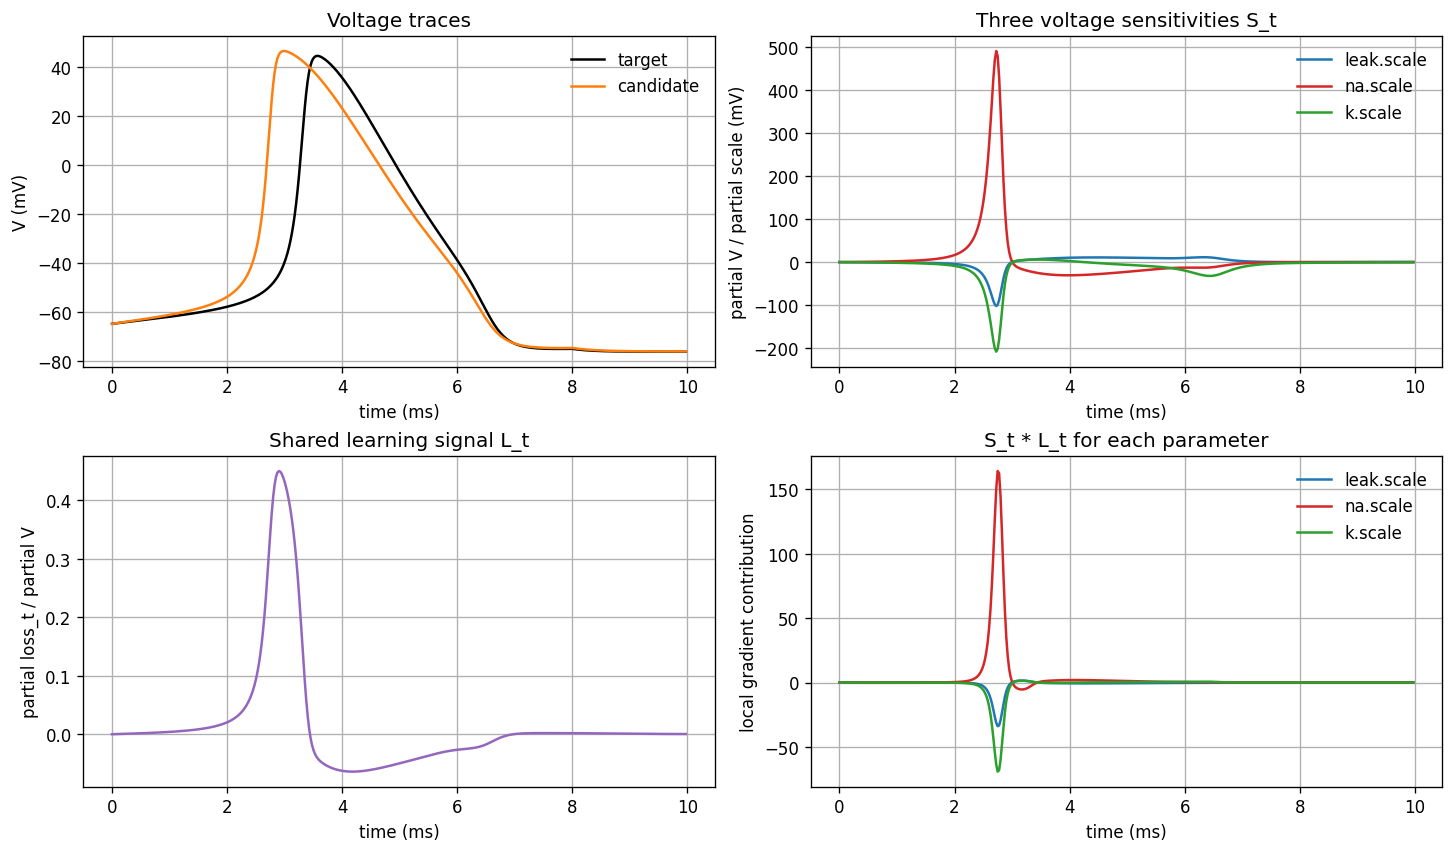

In [5]:
time = np.asarray(times_ms)
colors = ("tab:blue", "tab:red", "tab:green")
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

axes[0, 0].plot(time, np.asarray(target_voltage_mv), label="target", color="black")
axes[0, 0].plot(time, np.asarray(candidate_voltage_mv), label="candidate", color="tab:orange")
axes[0, 0].set(xlabel="time (ms)", ylabel="V (mV)", title="Voltage traces")
axes[0, 0].legend(frameon=False)

for index, (name, color) in enumerate(zip(parameter_names, colors)):
    axes[0, 1].plot(time, S_voltage[:, index], label=name, color=color)
axes[0, 1].set(xlabel="time (ms)", ylabel="partial V / partial scale (mV)", title="Three voltage sensitivities S_t")
axes[0, 1].legend(frameon=False)

axes[1, 0].plot(time, L_voltage, color="tab:purple")
axes[1, 0].set(xlabel="time (ms)", ylabel="partial loss_t / partial V", title="Shared learning signal L_t")

for index, (name, color) in enumerate(zip(parameter_names, colors)):
    axes[1, 1].plot(time, contribution[:, index], label=name, color=color)
axes[1, 1].set(xlabel="time (ms)", ylabel="local gradient contribution", title="S_t * L_t for each parameter")
axes[1, 1].legend(frameon=False)
plt.show()

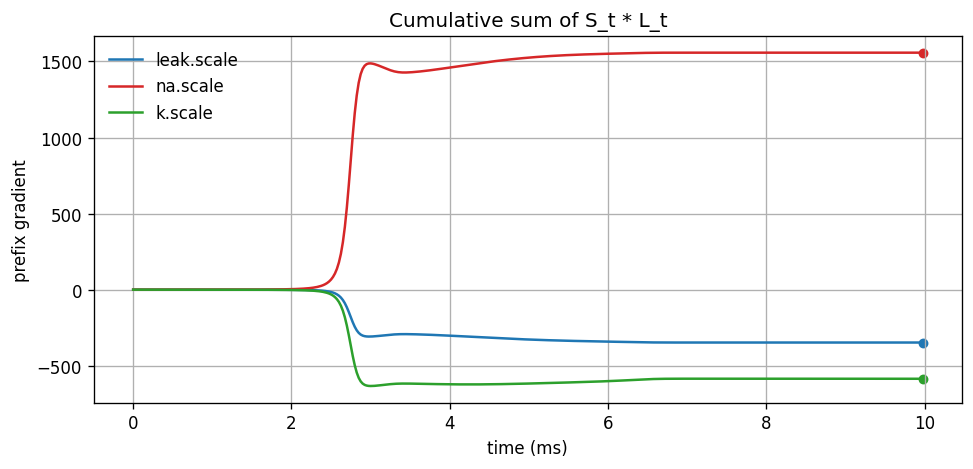

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
for index, (name, color) in enumerate(zip(parameter_names, colors)):
    ax.plot(time, prefix_gradient[:, index], label=name, color=color)
    ax.scatter(time[-1], total_gradient[index], color=color, s=24)
ax.set(xlabel="time (ms)", ylabel="prefix gradient", title="Cumulative sum of S_t * L_t")
ax.legend(frameon=False)
plt.show()

## 5. 让 S/L 分解随着 Adam epoch 变化

下面重新建立一个 candidate Cell，并训练 12 个 epoch。每个 epoch 都完整运行 400 步 RTRL diagnostics，保存紧凑的 voltage `S_t`、`L_t` 和乘积，再把 `sum_t S_t*L_t` 作为 raw gradient 交给 Adam。参数只在完整 rollout 结束后更新一次。

In [7]:
EPOCHS = 12
LEARNING_RATE = 0.01
ADAM_BETAS = (0.9, 0.999)
ADAM_EPS = 1e-8

with brainstate.environ.context(dt=DT, precision=64):
    training_cell = build_single_cv_cell(trainable=True)
    parameter_states = training_cell.trainables.parameters().states()
    optimizer = braintools.optim.Adam(
        lr=LEARNING_RATE,
        betas=ADAM_BETAS,
        eps=ADAM_EPS,
    )
    optimizer.register_trainable_weights(parameter_states)


def training_rollout_step(data):
    time_ms, target_mv = data
    voltage_mv = training_cell.V.value.to_decimal(u.mV)[0, 0]
    local_loss = (voltage_mv - target_mv) ** 2 / NUM_STEPS
    with brainstate.environ.context(t=time_ms * u.ms):
        training_cell.update()
    return local_loss


training_engine = build_rollout_value_and_grad(
    training_cell,
    step=training_rollout_step,
    method="rtrl",
)
with brainstate.environ.context(dt=DT, precision=64):
    training_engine.prepare((times_ms[0], target_voltage_mv[0]))
training_coordinates = training_engine._parameter_coordinates
training_names = tuple(training_coordinates.names)
training_states = tuple(training_engine._functional_step.state_trace.states)
training_voltage_index = next(index for index, state in enumerate(training_states) if state is training_cell.V)


# BrainState restores its default precision after each context; set JAX x64
# again before constructing the reusable diagnostic transform.
jax.config.update("jax_enable_x64", True)
diagnose_epoch = brainstate.transform.jit(lambda: training_engine.diagnose(step_data))


def train_epoch():
    diagnostic = diagnose_epoch()
    sensitivity = jax.tree.leaves(diagnostic.sensitivity[training_voltage_index])[0][:, :, 0, 0]
    learning_signal = jax.tree.leaves(diagnostic.learning_signal[training_voltage_index])[0][:, 0, 0]
    contribution = sensitivity * learning_signal[:, None]
    ordered_gradients = {name: diagnostic.gradients[name] for name in training_names}
    raw_gradient = training_coordinates.flatten(ordered_gradients)
    parameter_before = jnp.stack([parameter_states[name].value for name in training_names])

    optimizer.update(diagnostic.gradients)

    parameter_after = jnp.stack([parameter_states[name].value for name in training_names])
    adam_state = optimizer.opt_state.value[0]
    first_moment = jnp.stack([adam_state.mu[name] for name in training_names])
    second_moment = jnp.stack([adam_state.nu[name] for name in training_names])
    count = adam_state.count
    m_hat = first_moment / (1.0 - ADAM_BETAS[0] ** count)
    v_hat = second_moment / (1.0 - ADAM_BETAS[1] ** count)
    adam_direction = m_hat / (jnp.sqrt(v_hat) + ADAM_EPS)
    expected_delta = -LEARNING_RATE * adam_direction
    actual_delta = parameter_after - parameter_before
    voltage = target_voltage_mv + 0.5 * NUM_STEPS * learning_signal

    return {
        "loss": diagnostic.loss,
        "voltage": voltage,
        "sensitivity": sensitivity,
        "learning_signal": learning_signal,
        "contribution": contribution,
        "raw_gradient": raw_gradient,
        "parameter_before": parameter_before,
        "parameter_after": parameter_after,
        "first_moment": first_moment,
        "second_moment": second_moment,
        "adam_direction": adam_direction,
        "expected_delta": expected_delta,
        "actual_delta": actual_delta,
    }


records = []
with brainstate.environ.context(dt=DT, precision=64):
    for _ in range(EPOCHS):
        records.append(train_epoch())
    history = jax.tree.map(lambda *values: jnp.stack(values), *records)

In [8]:
epoch_loss = np.asarray(history["loss"])
voltage_history = np.asarray(history["voltage"])
sensitivity_history = np.asarray(history["sensitivity"])
learning_signal_history = np.asarray(history["learning_signal"])
contribution_history = np.asarray(history["contribution"])
prefix_history = np.cumsum(contribution_history, axis=1)
raw_gradient_history = np.asarray(history["raw_gradient"])
parameter_before_history = np.asarray(history["parameter_before"])
parameter_after_history = np.asarray(history["parameter_after"])
first_moment_history = np.asarray(history["first_moment"])
second_moment_history = np.asarray(history["second_moment"])
adam_direction_history = np.asarray(history["adam_direction"])
expected_delta_history = np.asarray(history["expected_delta"])
actual_delta_history = np.asarray(history["actual_delta"])

gradient_reconstruction_error = np.max(np.abs(np.sum(contribution_history, axis=1) - raw_gradient_history))
adam_reconstruction_error = np.max(np.abs(expected_delta_history - actual_delta_history))

print(f"loss: {epoch_loss[0]:.6f} -> {epoch_loss[-1]:.6f}")
print(f"max |sum_t S_t*L_t - raw gradient|: {gradient_reconstruction_error:.3e}")
print(f"max |reconstructed Adam delta - actual delta|: {adam_reconstruction_error:.3e}")
print("Adam clipping:", optimizer.grad_clip_norm, optimizer.grad_clip_value)
print("final scales:", dict(zip(training_names, parameter_after_history[-1])))

loss: 400.307572 -> 111.863973
max |sum_t S_t*L_t - raw gradient|: 2.274e-13
max |reconstructed Adam delta - actual delta|: 1.596e-16
Adam clipping: None None
final scales: {'leak.scale': np.float64(1.1200828781491736), 'na.scale': np.float64(0.8796810911479409), 'k.scale': np.float64(1.1205588357404024)}


## 6. Raw gradient 与 Adam 实际更新不是同一个量

`prefix_gradient[-1] = sum_t S_t*L_t` 是传入 Adam 的 raw gradient，不是 loss。当前 optimizer 的 clipping 配置均为 `None`，所以没有截断。Adam 会把 raw gradient 更新为一阶矩 `m` 和二阶矩 `v`，进行 bias correction，再乘 learning rate 得到实际 `delta scale`。

这里优化的是无量纲 scale：`gmax = baseline_gmax * scale`，所以 `dL/dscale = baseline_gmax * dL/dgmax`，而物理变化为 `delta gmax = baseline_gmax * delta scale`。直接学习物理 `gmax` 会改变梯度单位与 optimizer 轨迹。

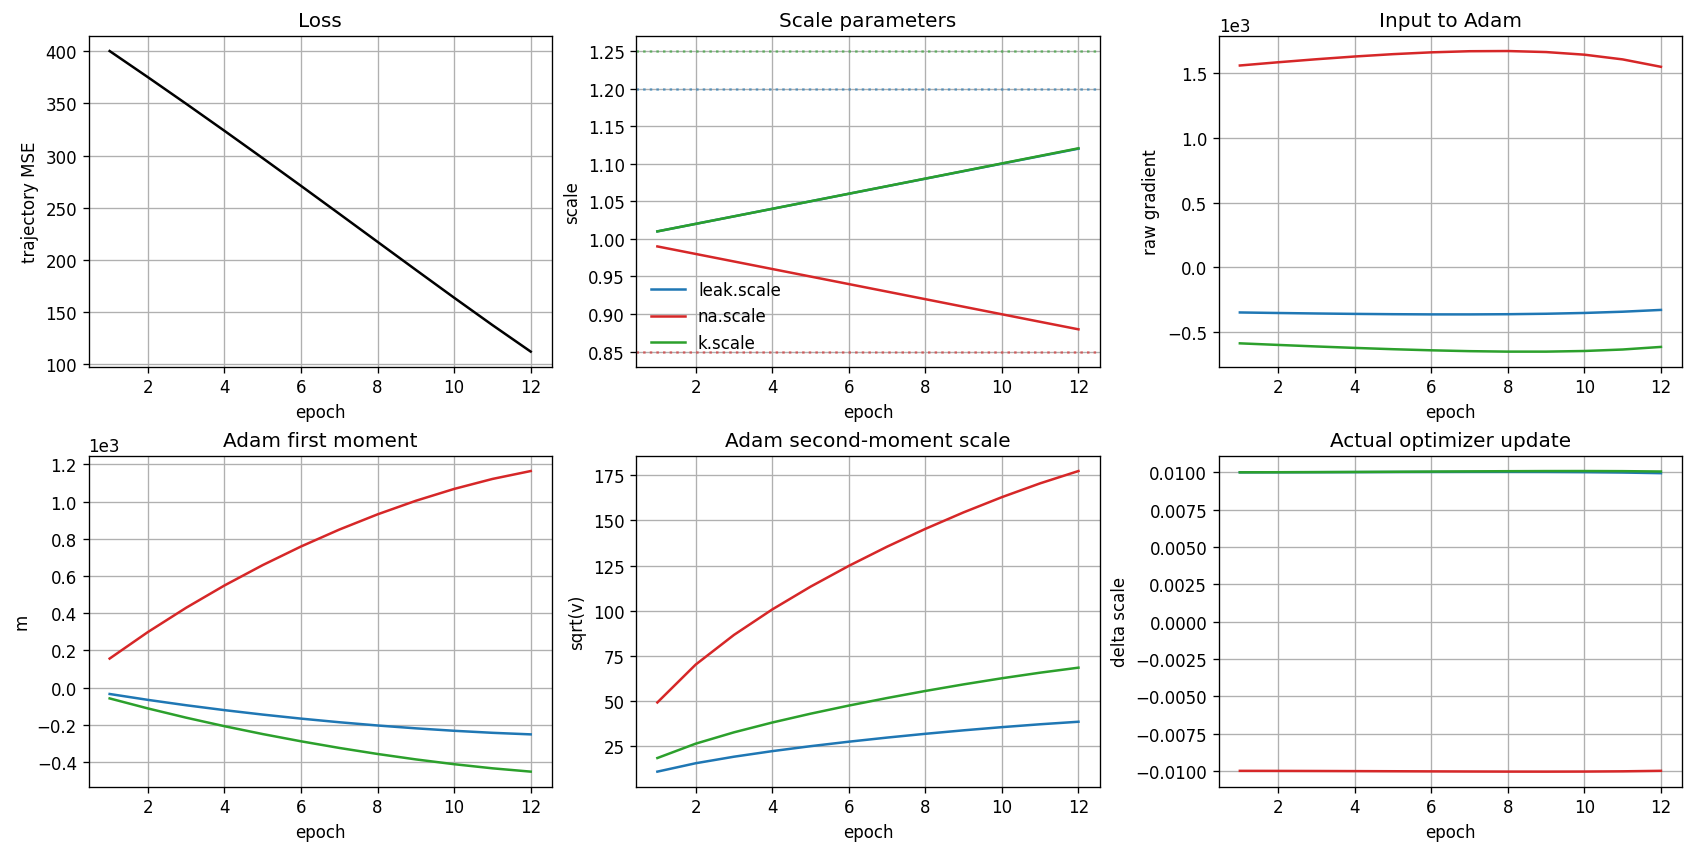

In [9]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)

axes[0, 0].plot(epochs, epoch_loss, color="black")
axes[0, 0].set(xlabel="epoch", ylabel="trajectory MSE", title="Loss")

for index, (name, color) in enumerate(zip(training_names, colors)):
    axes[0, 1].plot(epochs, parameter_after_history[:, index], label=name, color=color)
    axes[0, 1].axhline(TARGET_SCALES[name.split(".")[0]], color=color, linestyle=":", alpha=0.6)
axes[0, 1].set(xlabel="epoch", ylabel="scale", title="Scale parameters")
axes[0, 1].legend(frameon=False)

for index, (name, color) in enumerate(zip(training_names, colors)):
    axes[0, 2].plot(epochs, raw_gradient_history[:, index], label=name, color=color)
axes[0, 2].set(xlabel="epoch", ylabel="raw gradient", title="Input to Adam")

for index, (name, color) in enumerate(zip(training_names, colors)):
    axes[1, 0].plot(epochs, first_moment_history[:, index], label=name, color=color)
axes[1, 0].set(xlabel="epoch", ylabel="m", title="Adam first moment")

for index, (name, color) in enumerate(zip(training_names, colors)):
    axes[1, 1].plot(epochs, np.sqrt(second_moment_history[:, index]), label=name, color=color)
axes[1, 1].set(xlabel="epoch", ylabel="sqrt(v)", title="Adam second-moment scale")

for index, (name, color) in enumerate(zip(training_names, colors)):
    axes[1, 2].plot(epochs, actual_delta_history[:, index], label=name, color=color)
axes[1, 2].set(xlabel="epoch", ylabel="delta scale", title="Actual optimizer update")
for ax in axes.flat:
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
plt.show()

## 7. 拖动 epoch 查看整条时间分解如何变化

Slider 同步更新 voltage、三条 sensitivity、归一化/未归一化 learning signal、三条乘积贡献和 prefix gradient。最后一个面板列出该 epoch 的 raw gradient、Adam moment 与实际更新。

In [10]:
def plot_epoch(epoch_index):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
    voltage = voltage_history[epoch_index]
    sensitivity = sensitivity_history[epoch_index]
    normalized_L = learning_signal_history[epoch_index]
    raw_error_signal = NUM_STEPS * normalized_L
    contribution = contribution_history[epoch_index]
    prefix = prefix_history[epoch_index]

    axes[0, 0].plot(time, np.asarray(target_voltage_mv), label="target", color="black")
    axes[0, 0].plot(time, voltage, label="candidate", color="tab:orange")
    axes[0, 0].set(xlabel="time (ms)", ylabel="V (mV)", title=f"Voltage, epoch {epoch_index + 1}")
    axes[0, 0].legend(frameon=False)

    for index, (name, color) in enumerate(zip(training_names, colors)):
        axes[0, 1].plot(time, sensitivity[:, index], label=name, color=color)
    axes[0, 1].set(xlabel="time (ms)", ylabel="partial V / partial scale", title="S_t")
    axes[0, 1].legend(frameon=False)

    axes[1, 0].plot(time, normalized_L, color="tab:purple", label="L_t = 2 error / 400")
    raw_axis = axes[1, 0].twinx()
    raw_axis.plot(time, raw_error_signal, color="gray", linestyle="--", label="2 error")
    axes[1, 0].set(xlabel="time (ms)", ylabel="normalized L_t", title="Learning signal")
    raw_axis.set_ylabel("unnormalized 2(V-target)")
    axes[1, 0].legend(frameon=False, loc="upper left")
    raw_axis.legend(frameon=False, loc="upper right")

    for index, (name, color) in enumerate(zip(training_names, colors)):
        axes[1, 1].plot(time, contribution[:, index], label=name, color=color)
    axes[1, 1].set(xlabel="time (ms)", ylabel="local gradient", title="S_t * L_t")
    axes[1, 1].legend(frameon=False)

    for index, (name, color) in enumerate(zip(training_names, colors)):
        axes[2, 0].plot(time, prefix[:, index], label=name, color=color)
    axes[2, 0].set(xlabel="time (ms)", ylabel="prefix gradient", title="Cumulative gradient")
    axes[2, 0].legend(frameon=False)

    axes[2, 1].axis("off")
    lines = [f"epoch {epoch_index + 1}", f"loss = {epoch_loss[epoch_index]:.6g}", ""]
    for index, name in enumerate(training_names):
        lines.extend(
            [
                name,
                f"  scale: {parameter_before_history[epoch_index, index]:.5f} -> {parameter_after_history[epoch_index, index]:.5f}",
                f"  raw grad: {raw_gradient_history[epoch_index, index]: .4e}",
                f"  m / sqrt(v): {first_moment_history[epoch_index, index]: .4e} / {np.sqrt(second_moment_history[epoch_index, index]):.4e}",
                f"  delta: {actual_delta_history[epoch_index, index]: .4e}",
            ]
        )
    axes[2, 1].text(0.02, 0.98, "\n".join(lines), va="top", family="monospace", fontsize=9)
    plt.show()

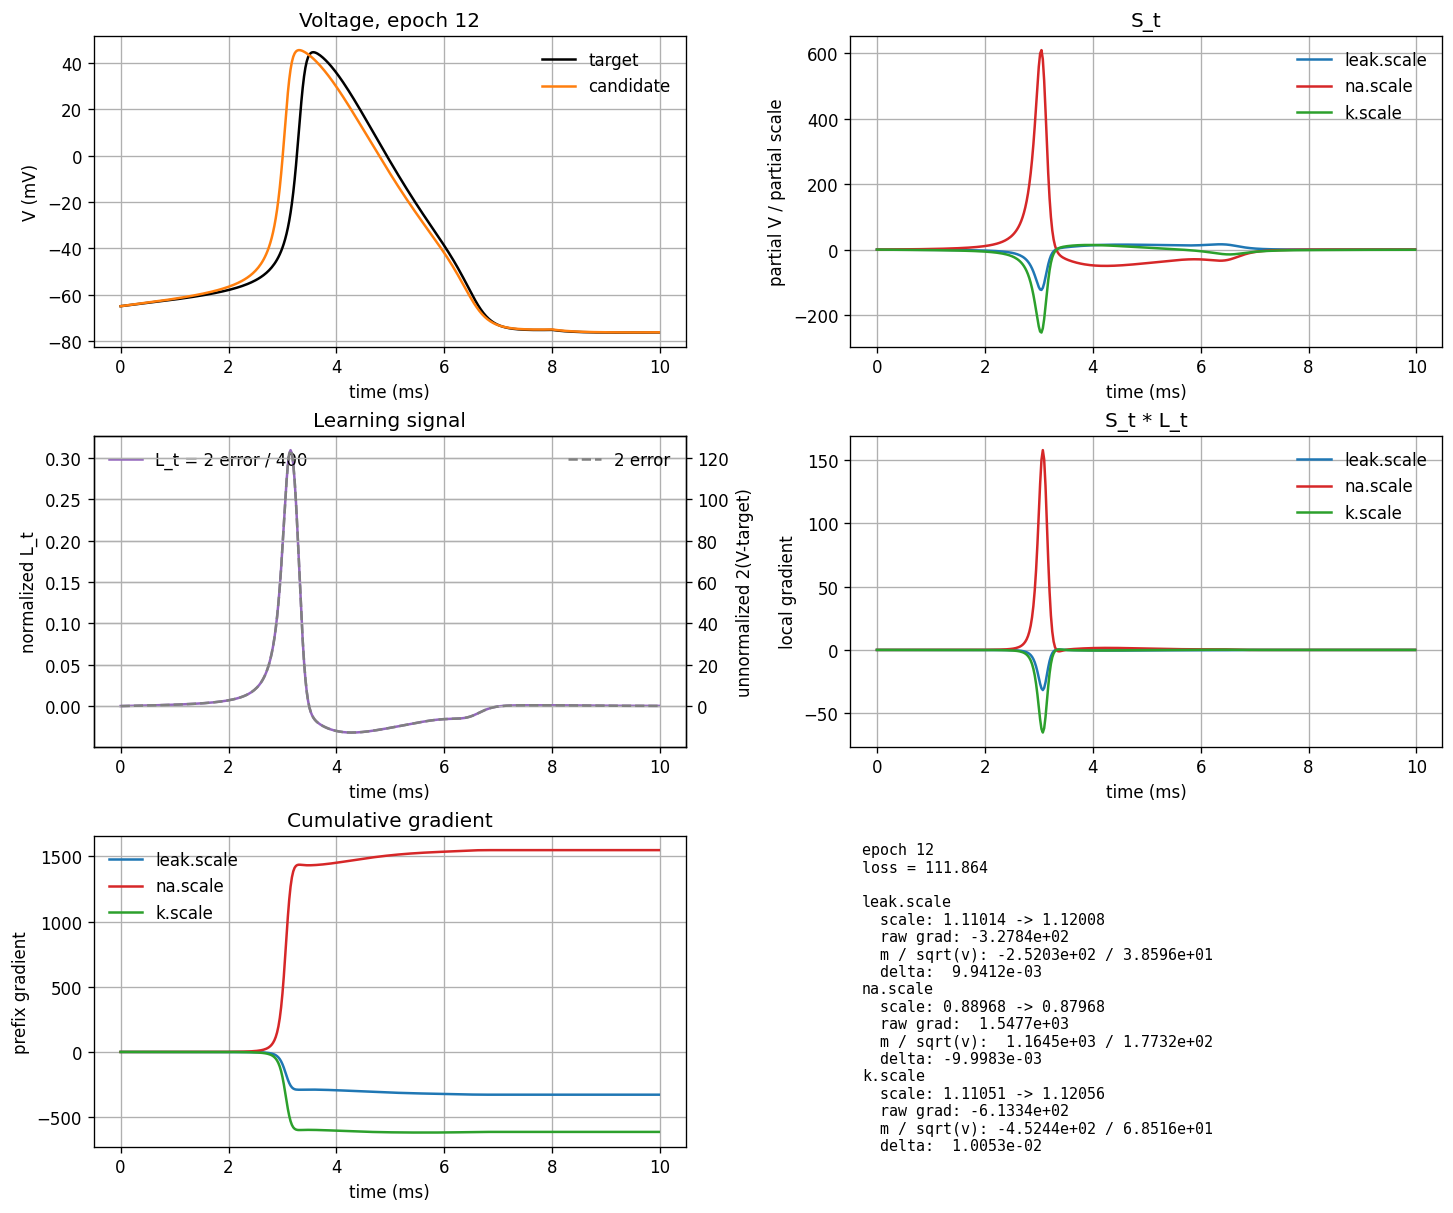

In [11]:
# 保存一个静态末 epoch 图，确保非交互 notebook viewer 也能看到结果。
plot_epoch(EPOCHS - 1)

In [ ]:
epoch_slider = widgets.IntSlider(
    value=EPOCHS - 1,
    min=0,
    max=EPOCHS - 1,
    step=1,
    description="epoch",
    continuous_update=False,
)
epoch_output = widgets.interactive_output(plot_epoch, {"epoch_index": epoch_slider})
display(widgets.VBox([epoch_slider, epoch_output]))

## 结论

- 单 CV 使每个参数在每个时刻只有一个 voltage sensitivity，三条曲线可以直接比较。
- 三个参数共享同一个 `L_t`，因为当前局部 loss 只依赖同一个膜电位。
- `S_t*L_t` 是每个参数的逐步梯度贡献；沿时间累加后就是 normal RTRL 返回的总梯度。
- `diagnose(at=None)` 会保存完整时间历史，只应用于分析；正常训练仍只携带当前 sensitivity。
- 每个 epoch 的 prefix 终点是交给 Adam 的 raw gradient；Adam 再通过 `m/v` 和 bias correction 产生实际 scale update。
- Epoch slider 展示了参数改变后 `S_t`、`L_t` 和 `S_t*L_t` 的整条时间结构如何共同变化。